In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
%matplotlib inline

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [2]:
# get unique chars that occur in the data
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [3]:
# Tokenization (we are building a character level language model so this is just mapping characters to integers)
# Define tokenizer
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder:

# Tokenize the data
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)

torch.Size([1115394]) torch.int64


In [4]:
# Split data into train and validation sets
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [5]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel (every forward and backward pass of the transformer)?
block_size = 8 # what is the maximum context length for predictions? (repeat from above)


def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,)) # dims ?
    x = torch.stack([data[i:i+block_size] for i in ix]) # stack ? is this like append in numpy for tensors?
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train') # get batch of chunks
print("inputs:")
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

# ================================================
# For each batch, process each chunk in the batch in parallel

# So here is one design decision that parts ways from the MLP architecture:
# We dont not have a fixed context size (that is just block_size). This is purposeful (not just efficiency)
# This is so that the transformer is able to expect any context length (up to block_size). This means that during inference, we can sample with any context length we want (up to block_size)
# so here we define the "time dimension" of the transformer (how it reads in data)

# Now we define the "batch dimension" of the transformer (how it processes data in parallel)
# This is simply done for efficiency (GPUs are very good at parallel processing). Each chunk (batch) is processed totally independently
# (this is not the self-attention mechanism)

for b in range(batch_size):
    for t in range(block_size):
        context = xb[b, :t+1] # note the variable context length (up to block_size)
        target = yb[b, t]
        #print(f'when b={b} and t={t}, the context is "{context.tolist()}" and the target is "{target}"')

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])


In [6]:
class BigramLanguageModel(nn.Module):
    
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    
    def forward(self, idx, targets=None):
        # idx and targets are both (B,T) tensors of integers
        logits = self.token_embedding_table(idx) # (B,T,C) where C = vocab_size. (Batch, Time, Channel)
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) # reshape to (B*T, C)
            targets = targets.view(B*T) # reshape to (B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get predictions
            logits, loss = self(idx) # self(idx, targets=None) goes to forward(self, idx, targets)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
    
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)

print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


lfJeukRuaRJKXAYtXzfJ:HEPiu--sDioi;ILCo3pHNTmDwJsfheKRxZCFs
lZJ XQc?:s:HEzEnXalEPklcPU cL'DpdLCafBheH


In [7]:
# create PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [8]:
batch_size = 32
for steps in range(10000):
    
    # sample a batch of data
    xb, yb = get_batch('train')
    
    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    
print(loss.item())

2.362441062927246


In [9]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


M:
IUSh t,
F th he d ke alved.
Thupld, cipbll t
I: ir w, l me sie hend lor ito'l an e

I:
Gochosen ea ar btamandd halind
Aust, plt t wadyotl
I bel qunganonoth he m he de avellis k'l, tond soran:

WI he toust are bot g e n t s d je hid t his IAces I my ig t
Ril'swoll e pupat inouleacends-athiqu heamer te
Wht s

MI wect!-lltherotheve t fe;
WAnd py;

PO t s ld tathat, ir V
IO thesecin teot tit ado ilorer.
Ply, d'stacoes, ld omat mealellly yererer EMEvesas ie IZEd pave mautoofareanerllleyomerer but?


# Self-Attention

In [10]:
# consider the toy example

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [11]:
# within a single batch, we want the tokens to talk to eachother - not be independent
# the flow of information is from all previous tokens to the current token. the current token does not talk to future tokens following it
# this is because this current token is trying to predict the future tokens
# So, we want x[b, t] = mean{i<=t} x[b,i]
xbow = torch.zeros((B,T,C)) # xbow = x bag of words. bag of words is a term that signifies that you're just averaging a ton of words
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t, C). This is the previous chunk of tokens from the sequence, including the current token (t-th)
        xbow[b,t] = torch.mean(xprev, 0) # this takes the average over the 0-th dimension, which is time

# so xbow[b,t] holds a vector that encodes (via mean) all tokens up to and including the token at position t, in the sequence of batch b

In [12]:
# the math trick used in self attention is to do the above efficiently with matrix mult
# using the normalized lower triangular matrix a, we find that
# c[i, j] = the mean of the first i entries of column j of b
a = torch.ones(4, 4)
#for i in range(len(a)):
#    a[i,:] /= i+1
a = a / torch.sum(a, 1, keepdim=True)
a = torch.tril(a)
print(a)

b = torch.randint(0,10, (4,2)).float()
print(b)
c = a @ b
print(c)

tensor([[0.2500, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500]])
tensor([[8., 6.],
        [5., 2.],
        [4., 4.],
        [7., 4.]])
tensor([[2.0000, 1.5000],
        [3.2500, 2.0000],
        [4.2500, 3.0000],
        [6.0000, 4.0000]])


In [13]:
# Thus define weights matrix wei

wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x 
# (T, T) x (B, T, C) ---> PyTorch creates batch dimension ---> (B, T, T) x (B, T, C) 
# (B, T, T) x (B, T, C) is a batched matrix multiply: applies matrix mult to each batch in parallel
# (B, T, T) x (B, T, C) = (B, T, C)

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0.,

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

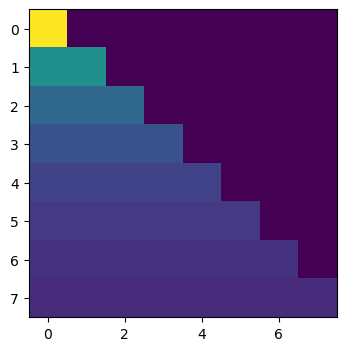

In [14]:
# Version 3: use softmax
tril = torch.tril(torch.ones(T, T))
print(tril)
wei = torch.zeros((T, T))
print(wei)
wei = wei.masked_fill(tril == 0, float('-inf'))
print(wei)
wei = F.softmax(wei, dim=-1) # softmax along every row (which exponentiates and then normalizes)
plt.figure(figsize=(4,4))
plt.imshow(wei)
xbow3 = wei @ x
wei

# we can think of the weights in wei as an interaction strength:
# how much do we want each token to contribute to the average that encodes all tokens up to the current token?
# and we only allow tokens from the past to communicate, not the future

## Version 4: Self-attention

Above we see how we can allow every token to be dependent on all previous tokens

But some past tokens are more important than other - the "affinities" between some tokens are stronger than between others

We do not want to take a simple uniformly weighted mean of the entire history of that sequence (batch)

We want to discover which tokens' affinities are stronger than others, and give these tokens more predictive power (stronger weight in 
the mean)

Thus, every single node / token at each position emits 2 vectors, a key and a query: 

 * Key: For each token, asks "what do I contain?"

 * Query: For each token, asks "what am I looking for?"

We then let the weight matrix (tensor because of batches) be defined by the dot product of all the queries with all the keys

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1687, 0.8313, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2477, 0.0514, 0.7008, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4410, 0.0957, 0.3747, 0.0887, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0069, 0.0456, 0.0300, 0.7748, 0.1427, 0.0000, 0.0000, 0.0000],
         [0.0660, 0.089

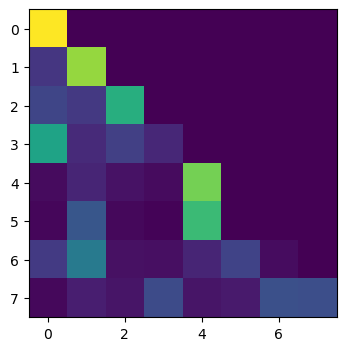

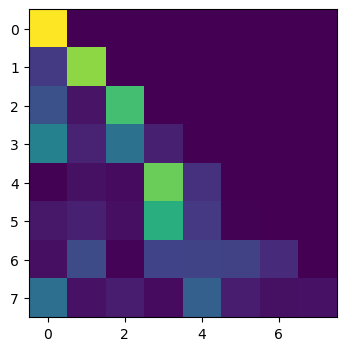

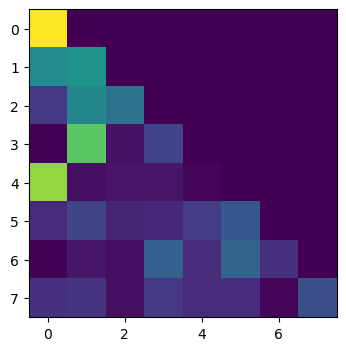

In [15]:
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channel
# so what these numbers mean are: 
#   have four batches that get processed in parallel for efficiency
#   have 8 tokens per batch (sequential in "time", as far as information flow)
#   and each token is encoded as a 32 dimensional vector
x = torch.randn(B,T,C)

# Let a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
# Let all tokens in x independently produce a key and a query by forwarding these layers onto x (the data)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)


tril = torch.tril(torch.ones(T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
v = value(x)
out = wei @ v


# print statements
print(wei)
plt.figure(figsize=(4,4))
plt.imshow(wei[0].detach().numpy())
plt.figure(figsize=(4,4))
plt.imshow(wei[1].detach().numpy())
plt.figure(figsize=(4,4))
plt.imshow(wei[2].detach().numpy())

### Some notes about attention (@ ~1:11:30)

* attention is a communication mechanism. Have nodes on a directed graph. Each node has information. Attention is a way of each node taking a weighted sum of all of the information from all the nodes pointing to it. Data dependent weights. Our autoregressive language modeling application will have a specific structure of graph, but attention can be applied to any arbitrary directed graph.

* There is no notion of space (unlike in a convolution layer). Attention simply acts on a set of vectors. Thus since we want information about space, we need to manually add the positional encodings.

* batch dimensions are totally independent (happen in parallel)

* An "encoder" attention block just deletes the single line that applies the ```tril``` mask to ```wei```, allowing all tokens to communication. This would be done for an application like sentiment analysis of test, rather than a generative program that needs to be trained autoregressively. What we have above is a "decoder". I know that you can view these as maps into and out of a latent space of semantic vectors - still need to see that math in a bit more detail. Where is the latent space in the architecture here?

* "self-attention" (like what we have here) means that the keys, queries, and values all come from the same source: ```x```. As opposed to: in encoder-decoder transformers, you can have the case where the queries are produced from ```x```, but the keys and values come from an external source (for example, the encoder blocks that encode context that we would like to condition on). This is "cross-attention", which generally, means there is a separate source of nodes that we would like to pull information from into our nodes (our queries).

* Scaled Dot-Product Attention: We divide ```wei``` by 1/sqrt(head_size). $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
This is so that when the input K, Q are unit variance, ```wei``` will also be unit variance and after we apply softmax, the probabilities will stay diffuse and not saturate too much. If we had extreme values of ```wei```, then the softmax would basically converge to e_i = (0,0,...,1,...,0,0) = one hot encoding. Thus we lose all of the naunced information that was the entire point of atention. (Especially don't want extreme values at initialization)


In [16]:
class LayerNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
    def __call__(self, x):
        xmean = x.mean(1, keepdim=True)
        xvar = x.var(1, keepdim=True)
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        return self.out
    
    def parameter(self):
        return [self.gamma, self.beta]
    
module = LayerNorm1d(100)
x = torch.randn(32, 100)
x = module(x)

In [17]:
x[0,:].mean(), x[0,:].std()

(tensor(0.), tensor(1.0000))

In [18]:
# whereas for batch norm it is this dim that would have been normalized:
x[:,0].mean(), x[:,0].std()

(tensor(0.0285), tensor(1.0501))